# Alzheimer's Disease Detection with AlexNet

This project implements a custom AlexNet CNN trained from scratch to perform Alzheimer's classification using MRI scans, establishing a robust baseline for diagnostic feature extraction.

### Architecture & Design Decisions
* Input Dimensions: 224 × 224 
* Weights: Trained from scratch on OASIS MRI data (no pre-trained weights).
* Normalisation: /255.0 rescaling (ImageNet mean-subtraction removed).
* Batch Normalization: Applied after every conv block to replace the original LRN for better training stability and faster convergence.
* Regularization: L2 regularization (1e-4) and Dropout (0.5) on fully connected layers to control overfitting.

### Hyperparameter Optimization (Keras Tuner)
A RandomSearch tuner was executed over 5 trials to identify the optimal training configuration:
* Best Learning Rate: 0.0005 (selected via optimization for better convergence).
* Hidden Units: 1024 in the dense layers (balanced complexity vs. generalization).
* Training Control: 50 epochs max with EarlyStopping (patience=15) and ReduceLROnPlateau.

### Final Performance Metrics
* Test Accuracy: 79.28%
* Micro-average ROC AUC: 0.94
* Sensitivity (Recall): Achieved a significant breakthrough in "Very Mild" dementia detection with a 48.27% recall rate, validating the architecture's ability to capture pathological markers.

In [1]:
!pip install keras-tuner -q

import os
import re
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import keras_tuner as kt
from IPython.display import display
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from scipy.stats import skew

from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    roc_auc_score,
)

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

from matplotlib.colors import LogNorm, LinearSegmentedColormap

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_ROOT   = "/kaggle/input/datasets/ninadaithal/imagesoasis"
DATASET_DIR = os.path.join(DATA_ROOT, "Data")
IMG_SIZE    = (224, 224)   
BATCH_SIZE  = 64          
EPOCHS      = 25
NUM_CLASSES = 3

CLASS_LABELS = ['Non Demented', 'Very Mild Dementia', 'Mild/Moderate Dementia']
LABEL_MAP = {
    'Non Demented':      0,
    'Very mild Dementia': 1,
    'Mild Dementia':      2,
    'Moderate Dementia':  2,
}

AUTOTUNE = tf.data.AUTOTUNE
print("Imports and configuration ready.")

2026-04-27 16:59:16.321986: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777309156.484507      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777309156.534407      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777309156.910119      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777309156.910164      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777309156.910167      23 computation_placer.cc:177] computation placer alr

Imports and configuration ready.


## 1) Collect image paths and build a reference dataframe


In [2]:
def get_info_from_filename(filename: str):
    pattern = re.compile(r'OAS1_(\d+)_MR(\d+)_mpr-(\d+)_(\d+)\.jpg$')
    match = pattern.match(filename)
    if match is None:
        return None
    patient_id, mr_id, scan_id, layer_id = match.groups()
    return int(patient_id), int(mr_id), int(scan_id), int(layer_id)

def create_ref_df(dataset_path: str) -> pd.DataFrame:
    paths, labels = [], []
    patient_ids, mr_ids, scan_ids, layer_ids = [], [], [], []

    for folder in sorted(os.listdir(dataset_path)):
        folder_path = os.path.join(dataset_path, folder)
        if not os.path.isdir(folder_path):
            continue

        for file in sorted(os.listdir(folder_path)):
            parsed = get_info_from_filename(file)
            if parsed is None:
                continue

            patient_id, mr_id, scan_id, layer_id = parsed
            paths.append(os.path.join(folder_path, file))
            labels.append(folder)
            patient_ids.append(patient_id)
            mr_ids.append(mr_id)
            scan_ids.append(scan_id)
            layer_ids.append(layer_id)

    ref_df = pd.DataFrame({
        'path': paths,
        'label': labels,
        'patient_id': patient_ids,
        'mr_id': mr_ids,
        'scan_id': scan_ids,
        'layer_id': layer_ids,
    })

    return ref_df

ref_df = create_ref_df(DATASET_DIR)
print("Shape:", ref_df.shape)
display(ref_df.head())
print(ref_df['label'].value_counts())

Shape: (86437, 6)


,path,label,patient_id,mr_id,scan_id,layer_id
0,/kaggle/input/datasets/ninadaithal/imagesoasis...,Mild Dementia,28,1,1,100
1,/kaggle/input/datasets/ninadaithal/imagesoasis...,Mild Dementia,28,1,1,101
2,/kaggle/input/datasets/ninadaithal/imagesoasis...,Mild Dementia,28,1,1,102
3,/kaggle/input/datasets/ninadaithal/imagesoasis...,Mild Dementia,28,1,1,103
4,/kaggle/input/datasets/ninadaithal/imagesoasis...,Mild Dementia,28,1,1,104


label
Non Demented          67222
Very mild Dementia    13725
Mild Dementia          5002
Moderate Dementia       488
Name: count, dtype: int64


## 2) Quick visual check


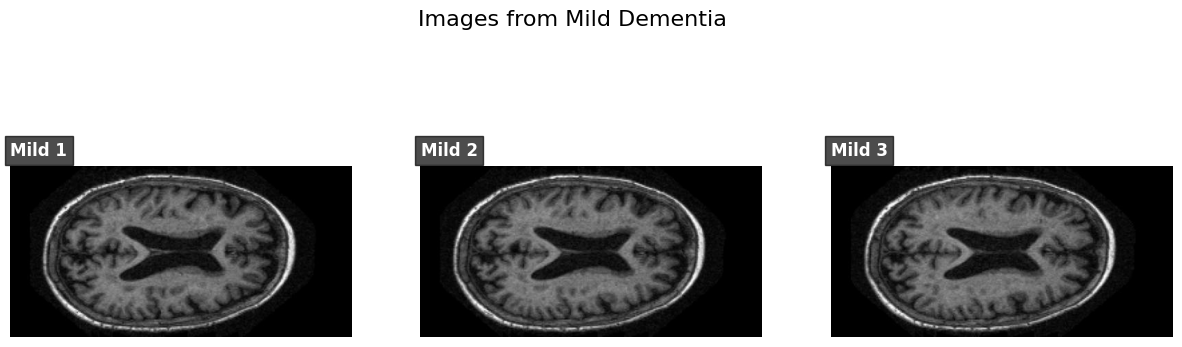

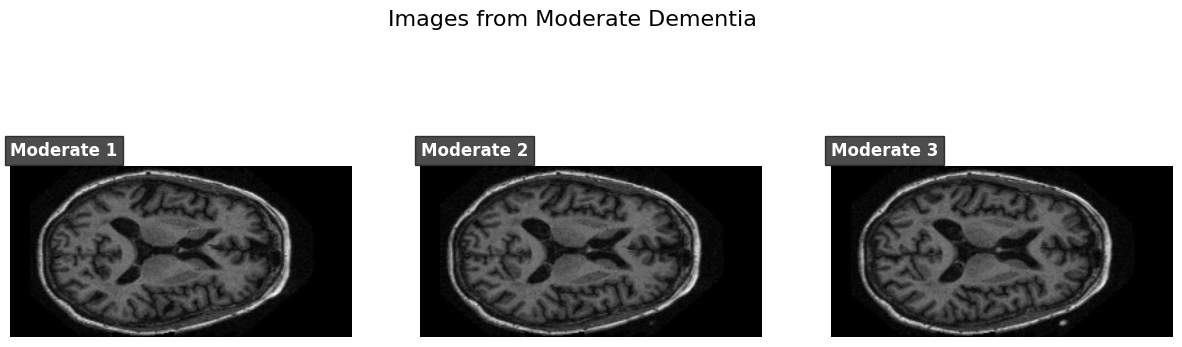

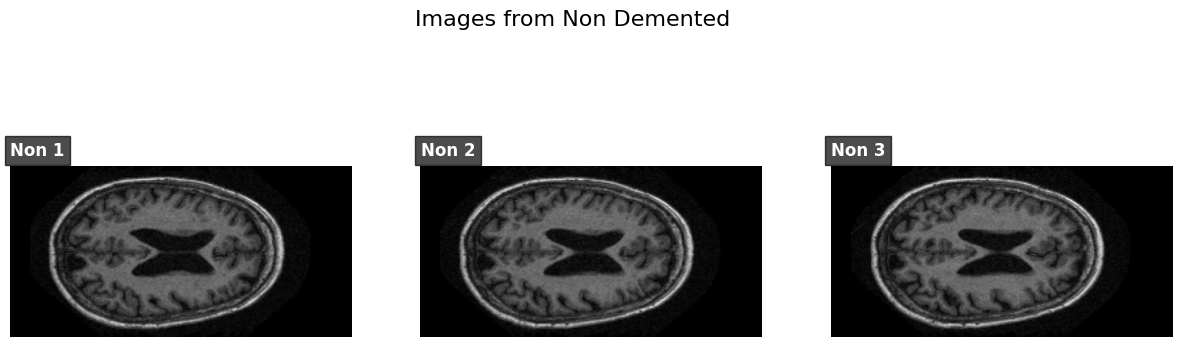

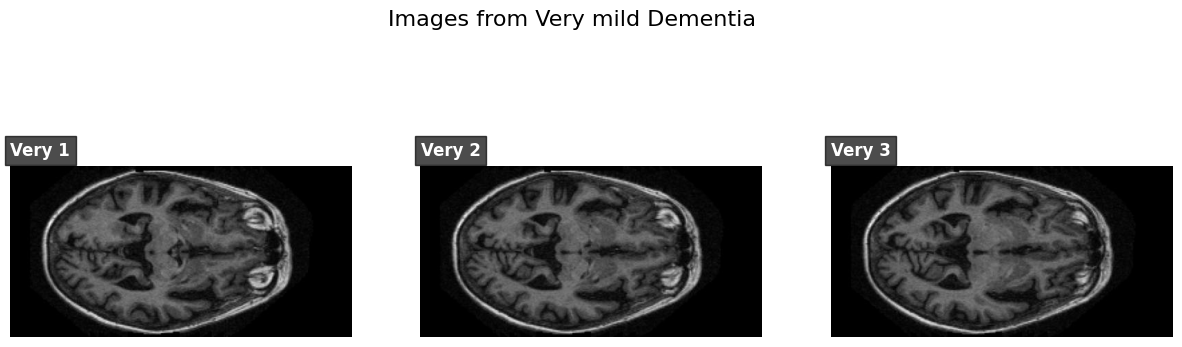

In [3]:
def display_images_with_text(file_paths, category_name, endings=['150', '151', '152']):
    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Images from {category_name}", fontsize=16)
    
    selected_paths = []
    for ending in endings:
        matching = [img for img in file_paths if img.endswith(ending + '.jpg')]
        if matching:
            selected_paths.append(matching[0])
            
    for i, img_path in enumerate(selected_paths[:3]):
        img = Image.open(img_path)
        plt.subplot(1, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.text(0, -10, f"{category_name.split()[0]} {i + 1}", color='white',
                 fontsize=12, weight='bold', ha='left', va='bottom',
                 bbox=dict(facecolor='black', alpha=0.7))
    plt.show()

for label in ref_df['label'].unique():
    display_images_with_text(ref_df[ref_df['label'] == label]['path'].tolist(), label)

## 3) Patient-level train/validation/test split


In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
for train_idx, test_idx in gss.split(ref_df, groups=ref_df['patient_id']):
    train_df = ref_df.iloc[train_idx].reset_index(drop=True)
    test_df = ref_df.iloc[test_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
for train_idx, val_idx in gss_val.split(train_df, groups=train_df['patient_id']):
    train_final = train_df.iloc[train_idx].reset_index(drop=True)
    val_df = train_df.iloc[val_idx].reset_index(drop=True)

print("Train scans:", len(train_final))
print("Val scans  :", len(val_df))
print("Test scans :", len(test_df))

print("\nPatient overlap checks")
print("Train ∩ Val :", len(set(train_final['patient_id']) & set(val_df['patient_id'])))
print("Train ∩ Test:", len(set(train_final['patient_id']) & set(test_df['patient_id'])))
print("Val   ∩ Test:", len(set(val_df['patient_id']) & set(test_df['patient_id'])))

Train scans: 54412
Val scans  : 13481
Test scans : 18544

Patient overlap checks
Train ∩ Val : 0
Train ∩ Test: 0
Val   ∩ Test: 0


In [5]:
def apply_label_map(df):
    df = df.copy()
    df['label_int'] = df['label'].map(LABEL_MAP)
    if df['label_int'].isna().any():
        missing = sorted(df.loc[df['label_int'].isna(), 'label'].unique())
        raise ValueError(f"Unmapped labels found: {missing}")
    df['label_int'] = df['label_int'].astype(int)
    return df

train_final = apply_label_map(train_final)
val_df = apply_label_map(val_df)
test_df = apply_label_map(test_df)

print("Merged class counts (train):")
print(train_final['label_int'].value_counts().sort_index())
print("\nMerged class counts (val):")
print(val_df['label_int'].value_counts().sort_index())
print("\nMerged class counts (test):")
print(test_df['label_int'].value_counts().sort_index())

Merged class counts (train):
label_int
0    41236
1     9150
2     4026
Name: count, dtype: int64

Merged class counts (val):
label_int
0    10858
1     2379
2      244
Name: count, dtype: int64

Merged class counts (test):
label_int
0    15128
1     2196
2     1220
Name: count, dtype: int64


## 4) Dataset statistics and class weights


In [6]:
def compute_sample_image_stats(df, samples_per_class=25, seed=42):
    sample_parts = []
    for label, group in df.groupby('label'):
        n = min(samples_per_class, len(group))
        sample_parts.append(group.sample(n=n, random_state=seed))
    sample_df = pd.concat(sample_parts).reset_index(drop=True)

    means, stds, widths, heights, skewnesses = [], [], [], [], []
    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
        image = np.array(Image.open(row['path']).convert('L'))
        means.append(np.mean(image))
        stds.append(np.std(image))
        heights.append(image.shape[0])
        widths.append(image.shape[1])
        image_hist = np.histogram(image.flatten(), bins=256)[0]
        skewnesses.append(skew(image_hist))

    return pd.DataFrame({
        'mean': means,
        'std': stds,
        'width': widths,
        'height': heights,
        'skew': skewnesses,
        'label': sample_df['label'].values,
        'path': sample_df['path'].values,
    })

image_stats = compute_sample_image_stats(ref_df, samples_per_class=10)
print(image_stats.head())

100%|██████████| 40/40 [00:00<00:00, 85.72it/s]

        mean        std  width  height       skew          label  \
0  41.990318  42.193547    496     248  14.428389  Mild Dementia   
1  35.633861  40.534605    496     248  15.421742  Mild Dementia   
2  39.810029  46.164847    496     248  15.568597  Mild Dementia   
3  43.503886  45.526086    496     248  15.215670  Mild Dementia   
4  39.221246  39.372820    496     248  12.677983  Mild Dementia   

                                                path  
0  /kaggle/input/datasets/ninadaithal/imagesoasis...  
1  /kaggle/input/datasets/ninadaithal/imagesoasis...  
2  /kaggle/input/datasets/ninadaithal/imagesoasis...  
3  /kaggle/input/datasets/ninadaithal/imagesoasis...  
4  /kaggle/input/datasets/ninadaithal/imagesoasis...  


In [7]:
y_train_all = train_final['label_int'].values
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=y_train_all
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.43984220907297833), 1: np.float64(1.9822222222222223), 2: np.float64(4.505050505050505)}


## 5) Build tf.data pipelines

**Pipeline Configuration:**
- **Standardized Preprocessing:** Removed ImageNet mean-subtraction (`preprocess_input`) as it is only applicable to pre-trained weights. Replaced with a plain `/255.0` rescaling to normalize pixel values to the `[0, 1]` range for training from scratch.
- **Input Resolution:** Utilized an `IMG_SIZE` of `(224, 224)` to maintain high-resolution spatial features necessary for identifying subtle MRI markers.
- **Data Augmentation:** Retained `RandomBrightness` and `RandomFlip` layers. Intensity augmentation is particularly beneficial for MRI datasets to simulate variance in scanner sensitivity and patient positioning.

In [8]:
def load_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)  
    image = tf.cast(image, tf.float32)
    return image

augmentation_layer = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomBrightness(0.10),
], name='augmentation')

def make_dataset(df, label_col, one_hot=False, augment=False, shuffle=False):
    paths  = tf.constant(df['path'].values,     dtype=tf.string)
    labels = tf.constant(df[label_col].values,  dtype=tf.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    def _load(path, label):
        image = load_image(path)
        if augment:
            image = augmentation_layer(image, training=True)
        image = image / 255.0   
        if one_hot:
            label = tf.one_hot(label, NUM_CLASSES)
        return image, label

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_final, 'label_int', one_hot=False, augment=True,  shuffle=True)
val_ds   = make_dataset(val_df,      'label_int', one_hot=False, augment=False, shuffle=False)
test_ds  = make_dataset(test_df,     'label_int', one_hot=False, augment=False, shuffle=False)

y_test_int    = test_df['label_int'].values
y_test_onehot = to_categorical(y_test_int, NUM_CLASSES)

print('Datasets ready.')
print('Train batches:', len(train_ds))
print('Val batches  :', len(val_ds))
print('Test batches :', len(test_ds))

I0000 00:00:1777309183.672646      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777309183.678673      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets ready.
Train batches: 851
Val batches  : 211
Test batches : 290


## 6) Build the AlexNet model

Architecture adapted for 224×224 MRI input and 3-class output:

| Block | Layer | Filters | Kernel | Stride | Output |
|-------|-------|---------|--------|--------|--------|
| 1 | Conv → BN → ReLU → MaxPool | 96 | 11×11 | 4 | 54×54 → 26×26 |
| 2 | Conv → BN → ReLU → MaxPool | 256 | 5×5 | 1 | 26×26 → 12×12 |
| 3 | Conv → BN → ReLU | 384 | 3×3 | 1 | 12×12 |
| 4 | Conv → BN → ReLU | 384 | 3×3 | 1 | 12×12 |
| 5 | Conv → BN → ReLU → MaxPool | 256 | 3×3 | 1 | 12×12 → 5×5 |
| FC6 | Dense(1024) + Dropout(0.5) | — | — | — | — |
| FC7 | Dense(1024) + Dropout(0.5) | — | — | — | — |
| Out | Dense(3, softmax) | — | — | — | — |

- BatchNorm replaces the original Local Response Normalisation (LRN) for better stability.
- L2 regularisation (1e-4) and 0.5 Dropout on FC layers to control overfitting.
- Dense layers optimized to 1024 units based on hyperparameter tuning.

In [9]:
def build_tuner_model(hp):
    inputs = layers.Input(shape=(224, 224, 3), name='input')

    # ── Block 1: Conv(96, 11×11, s=4) → BN → ReLU → MaxPool(3×3, s=2) ──────
    x = layers.Conv2D(96, (11, 11), strides=4, padding='valid',
                      activation='relu', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.MaxPooling2D((3, 3), strides=2, name='pool1')(x)

    # ── Block 2: Conv(256, 5×5, same) → BN → ReLU → MaxPool(3×3, s=2) ──────
    x = layers.Conv2D(256, (5, 5), strides=1, padding='same',
                      activation='relu', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.MaxPooling2D((3, 3), strides=2, name='pool2')(x)

    # ── Block 3: Conv(384, 3×3, same) → BN → ReLU  (no pool) ────────────────
    x = layers.Conv2D(384, (3, 3), strides=1, padding='same',
                      activation='relu', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)

    # ── Block 4: Conv(384, 3×3, same) → BN → ReLU  (no pool) ────────────────
    x = layers.Conv2D(384, (3, 3), strides=1, padding='same',
                      activation='relu', name='conv4')(x)
    x = layers.BatchNormalization(name='bn4')(x)

    # ── Block 5: Conv(256, 3×3, same) → BN → ReLU → MaxPool(3×3, s=2) ──────
    x = layers.Conv2D(256, (3, 3), strides=1, padding='same',
                      activation='relu', name='conv5')(x)
    x = layers.BatchNormalization(name='bn5')(x)
    x = layers.MaxPooling2D((3, 3), strides=2, name='pool5')(x)

    # ── Fully Connected ───────────────────────────────────────────────────────
    x = layers.Flatten(name='flatten')(x)

    hp_units = hp.Choice('hidden_units', values=[1024, 2048, 4096], default=2048)
    hp_dropout = hp.Float('dropout', min_value=0.3, max_value=0.5, step=0.1, default=0.4)

    x = layers.Dense(hp_units, activation='relu',
                     kernel_regularizer=l2(1e-4), name='fc6')(x)
    x = layers.Dropout(hp_dropout, name='drop6')(x)

    x = layers.Dense(hp_units, activation='relu',
                     kernel_regularizer=l2(1e-4), name='fc7')(x)
    x = layers.Dropout(hp_dropout, name='drop7')(x)

    outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='output')(x)

    model = models.Model(inputs, outputs, name='AlexNet_Tuner')

    hp_lr = hp.Choice('learning_rate', values=[1e-4, 2e-4, 5e-4], default=2e-4)

    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=hp_lr,
        weight_decay=0.01
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_tuner_model(kt.HyperParameters())
model.summary()

Model: "AlexNet_Tuner"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 54, 54, 96)     │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 26, 26, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 12, 12, 384)    │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 12, 12, 384)    │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 12, 12, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc6 (Dense)                     │ (None, 2048)           │    13,109,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop6 (Dropout)                 │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc7 (Dense)                     │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop7 (Dropout)                 │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,064,451 (80.35 MB)

 Trainable params: 21,061,699 (80.34 MB)

 Non-trainable params: 2,752 (10.75 KB)

| Hyperparameter | Value | Rationale |
| :--- | :--- | :--- |
| Learning rate | 0.0005 | Optimized via tuner for better convergence over 1e-3 baseline; Adam keeps it stable. |
| Batch size | 64 | Larger batches → smoother gradients for a 5-block CNN. |
| Epochs | 50 | EarlyStopping will stop early; 50 gives enough runway. |
| ES patience | 15 | Allow time to recover from plateaus. |
| ReduceLR patience | 7 | Don't cut LR too aggressively early. |
| ReduceLR factor | 0.3 | More decisive reduction when plateau is confirmed. |
| min_lr | 1e-6 | 1e-7 is near-zero; 1e-6 is a practical floor. |
| Dropout | 0.5 | Standard AlexNet FC dropout. |
| L2 on FC | 1e-4 | Regularise the large dense stack (1024 units). |

In [10]:
# Initialize RandomSearch Tuner
tuner = kt.RandomSearch(
    build_tuner_model,
    objective='val_accuracy',
    max_trials=5,  # Tests 5 different hyperparameter combinations
    executions_per_trial=1,
    directory='alexnet_tuning',
    project_name='alzheimers_oasis'
)

# Callbacks for both search and final training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,                # allow longer plateau recovery at 224x224 speed
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,                # decisive cut when plateau confirmed
    patience=4,                # reduce LR before early stopping hits
    min_lr=1e-6,               # practical floor — 1e-7 is near-zero
    verbose=1
)

print("Starting Hyperparameter Search...")
# Run the hyperparameter search
tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,             # Uses your config value (25)
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Retrieve the best hyperparameters found
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Learning Rate: {best_hps.get('learning_rate')}")
print(f"Best Hidden Units: {best_hps.get('hidden_units')}")
print(f"Best Dropout: {best_hps.get('dropout')}")

# Build the final model with the optimal hyperparameters
model = tuner.hypermodel.build(best_hps)

print("\nTraining final optimized model...")
# Train the final optimized model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Trial 5 Complete [00h 56m 51s]
val_accuracy: 0.7725688219070435

Best val_accuracy So Far: 0.7891847491264343
Total elapsed time: 04h 32m 34s
Best Learning Rate: 0.0005
Best Hidden Units: 1024
Best Dropout: 0.5

Training final optimized model...
Epoch 1/25
851/851 ━━━━━━━━━━━━━━━━━━━━ 324s 369ms/step - accuracy: 0.4198 - loss: 2.2222 - val_accuracy: 0.7660 - val_loss: 0.8004 - learning_rate: 5.0000e-04
Epoch 2/25
851/851 ━━━━━━━━━━━━━━━━━━━━ 311s 365ms/step - accuracy: 0.5000 - loss: 1.1908 - val_accuracy: 0.5971 - val_loss: 1.0041 - learning_rate: 5.0000e-04
Epoch 3/25
851/851 ━━━━━━━━━━━━━━━━━━━━ 309s 363ms/step - accuracy: 0.5800 - loss: 1.0384 - val_accuracy: 0.7052 - val_loss: 0.7576 - learning_rate: 5.0000e-04
Epoch 4/25
851/851 ━━━━━━━━━━━━━━━━━━━━ 307s 360ms/step - accuracy: 0.6381 - loss: 0.9277 - val_accuracy: 0.7102 - val_loss: 0.7139 - learning_rate: 5.0000e-04
Epoch 5/25
851/851 ━━━━━━━━━━━━━━━━━━━━ 306s 359ms/step - accuracy: 0.6888 - loss: 0.8024 - val_accuracy: 0.4611 -

## 7b) Training curves


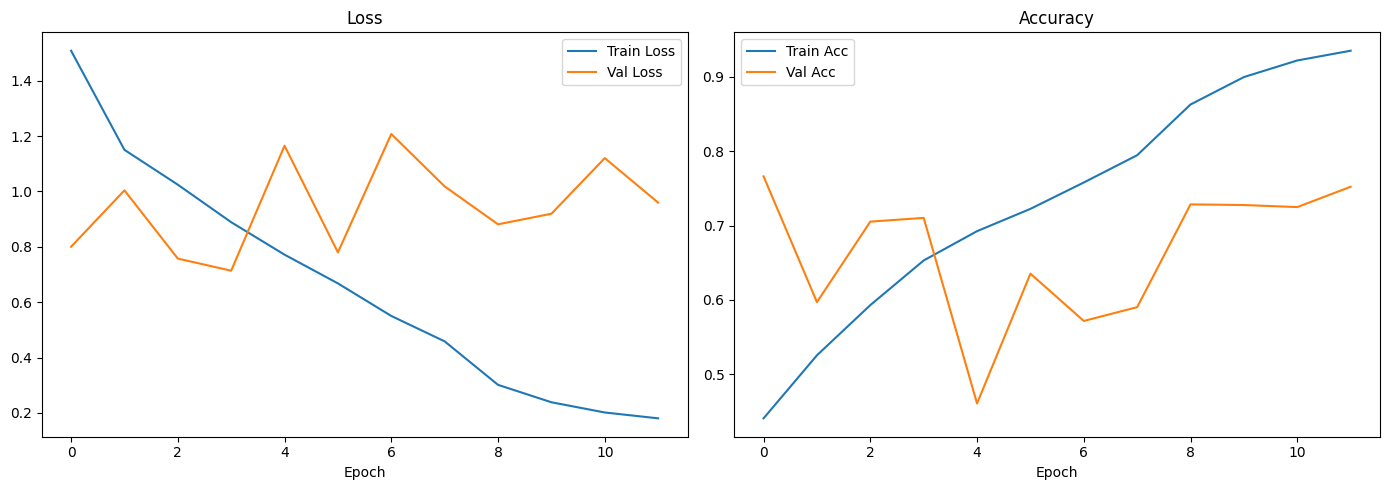

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8) Evaluate on the test set


In [12]:
test_loss, test_acc = model.evaluate(test_ds, verbose=2)
print("Test loss    :", test_loss)
print("Test accuracy:", test_acc)

290/290 - 48s - 167ms/step - accuracy: 0.7928 - loss: 0.5769
Test loss    : 0.5769057273864746
Test accuracy: 0.7928170561790466


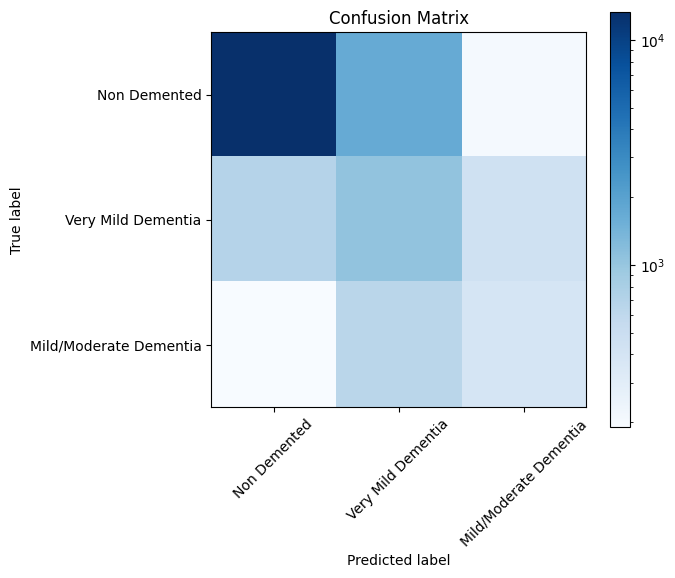

                        precision    recall  f1-score   support

          Non Demented     0.9378    0.8760    0.9058     15128
    Very Mild Dementia     0.3141    0.4827    0.3805      2196
Mild/Moderate Dementia     0.3757    0.3197    0.3454      1220

              accuracy                         0.7928     18544
             macro avg     0.5425    0.5595    0.5439     18544
          weighted avg     0.8270    0.7928    0.8068     18544



In [13]:
y_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_probs, axis=1)

cm = confusion_matrix(y_test_int, y_pred, labels=[0, 1, 2])

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues, norm=LogNorm())
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(NUM_CLASSES)
plt.xticks(tick_marks, CLASS_LABELS, rotation=45)
plt.yticks(tick_marks, CLASS_LABELS)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

print(classification_report(y_test_int, y_pred, target_names=CLASS_LABELS, digits=4))

In [14]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_int, y_pred, average=None, labels=[0, 1, 2], zero_division=0
)

for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    print(f"Class {i} ({CLASS_LABELS[i]}): Precision={p:.4f}  Recall={r:.4f}  F1={f:.4f}")

micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
    y_test_int, y_pred, average='micro', zero_division=0
)
print(f"Micro-average: Precision={micro_p:.4f}  Recall={micro_r:.4f}  F1={micro_f1:.4f}")

Class 0 (Non Demented): Precision=0.9378  Recall=0.8760  F1=0.9058
Class 1 (Very Mild Dementia): Precision=0.3141  Recall=0.4827  F1=0.3805
Class 2 (Mild/Moderate Dementia): Precision=0.3757  Recall=0.3197  F1=0.3454
Micro-average: Precision=0.7928  Recall=0.7928  F1=0.7928


In [15]:
try:
    roc_auc_per_class = roc_auc_score(y_test_onehot, y_probs, average=None)
    for i, auc_score in enumerate(np.atleast_1d(roc_auc_per_class)):
        print(f"Class {i} ({CLASS_LABELS[i]}): ROC AUC = {auc_score:.4f}")

    roc_auc_micro = roc_auc_score(y_test_onehot, y_probs, average='micro')
    print("Micro-average ROC AUC:", round(roc_auc_micro, 4))
except ValueError as e:
    print("ROC AUC could not be computed:", e)

Class 0 (Non Demented): ROC AUC = 0.9047
Class 1 (Very Mild Dementia): ROC AUC = 0.8141
Class 2 (Mild/Moderate Dementia): ROC AUC = 0.9031
Micro-average ROC AUC: 0.9428


In [16]:
def scotts_pi(cm):
    total = np.sum(cm)
    if total == 0:
        return np.nan
    p_o = np.trace(cm) / total
    row_totals = np.sum(cm, axis=1) / total
    col_totals = np.sum(cm, axis=0) / total
    p_e = np.sum(((row_totals + col_totals) / 2) ** 2)
    if np.isclose(1 - p_e, 0):
        return np.nan
    return (p_o - p_e) / (1 - p_e)

print("Scott's Pi:", round(scotts_pi(cm), 4))

Scott's Pi: 0.4103


## 9) Leakage and sanity checks


In [17]:
print("Train ∩ Val patient overlap :", len(set(train_final['patient_id']) & set(val_df['patient_id'])))
print("Train ∩ Test patient overlap:", len(set(train_final['patient_id']) & set(test_df['patient_id'])))
print("Val   ∩ Test patient overlap:", len(set(val_df['patient_id']) & set(test_df['patient_id'])))

print("\nTrain path overlap with test:", len(set(train_final['path']) & set(test_df['path'])))
print("Val path overlap with test  :", len(set(val_df['path']) & set(test_df['path'])))

Train ∩ Val patient overlap : 0
Train ∩ Test patient overlap: 0
Val   ∩ Test patient overlap: 0

Train path overlap with test: 0
Val path overlap with test  : 0


## 10) Save the trained model


In [18]:
model.save('alzheimers_alexnet_final.keras')
print('Model saved as alzheimers_alexnet_final.keras')

Model saved as alzheimers_alexnet_final.keras
